# D10: the density cost of a rotating gas vortex

A stationary Euler equilibrium with a fixed peak-speed radius. This is a known Gaussian isentropic family, not the proposed OpenAI collapse.

In [1]:
import json
import numpy as np
from IPython.display import Image, display
from nscomp.d10 import STUDY, WRITING, load_parameters, reference_gas, observable_rows, generate
from nscomp.compressible import IsentropicVortex, integrate_density, density_deficit_mach, local_gas_audit
p=load_parameters()
gas=reference_gas(p)

## Quantify the constitutive difference

The same swirl and exterior state give different interior densities. These are separate equilibria rather than evolutions of identical initial data.

In [2]:
for row in observable_rows(p):
    print(json.dumps(row,indent=2))
marker=float(density_deficit_mach(.05,gas.heat_capacity_ratio))
print('5% center-density marker:',marker,'; speed (m/s):',marker*gas.sound_speed)

{
  "peak_mach_using_exterior_sound": 0.1,
  "speed_m_s": 34.49837684587494,
  "center_density_ratio": 0.9864639585304248,
  "center_temperature_K": 294.5399616730037,
  "center_compressible_pressure_ratio": 0.9811009844246188,
  "center_incompressible_pressure_ratio": 0.9809720272007867,
  "maximum_local_mach": 0.10010025081956188
}
{
  "peak_mach_using_exterior_sound": 0.3,
  "speed_m_s": 103.4951305376248,
  "center_density_ratio": 0.8821293361668084,
  "center_temperature_K": 281.6596550570334,
  "center_compressible_pressure_ratio": 0.8389675655594567,
  "center_incompressible_pressure_ratio": 0.8287482448070802,
  "maximum_local_mach": 0.302762598083838
}
{
  "peak_mach_using_exterior_sound": 0.6,
  "speed_m_s": 206.9902610752496,
  "center_density_ratio": 0.5801271342896885,
  "center_temperature_K": 238.1886202281335,
  "center_compressible_pressure_ratio": 0.4665868028815196,
  "center_incompressible_pressure_ratio": 0.3149929792283207,
  "maximum_local_mach": 0.62380845226950

## Independently integrate radial density

The nonlinear radial RK4 solve only uses the analytic profile to set the optional exact outer boundary. Compare radial refinement against the closed-form interior.

In [3]:
v=IsentropicVortex(p['solver']['peak_mach'],gas.heat_capacity_ratio)
for n in p['solver']['interval_counts']:
    r,q=integrate_density(v,p['solver']['outer_radius_over_a'],n)
    err=np.max(np.abs(q-v.state(r)['density_ratio']))
    print(f'{n} intervals: maximum density error / exterior density = {err:.4g}')

24 intervals: maximum density error / exterior density = 3.376e-07
48 intervals: maximum density error / exterior density = 1.987e-08
96 intervals: maximum density error / exterior density = 1.205e-09
192 intervals: maximum density error / exterior density = 7.415e-11
384 intervals: maximum density error / exterior density = 4.599e-12


## Audit actual thermodynamic gradients and swirl shear

The gas mean-free-path correction is a local-property approximation. Radius is fixed at 1 mm independently of the earlier collapse anchor.

In [4]:
r=np.linspace(0,6,1601)
v=IsentropicVortex(.8,gas.heat_capacity_ratio)
audit=local_gas_audit(v,r,p['radius_m'],gas)
print('Sampled max thermodynamic Kn proxy:',np.max(audit['kn_pressure']))
print('Sampled max collision/shear ratio:',np.max(audit['collision_shear_ratio']))
print('Minimum temperature (K):',np.min(audit['temperature_K']))

Sampled max thermodynamic Kn proxy: 0.0001756348483717836
Sampled max collision/shear ratio: 5.85834585327875e-05
Minimum temperature (K): 193.10754707223728


## Regenerate and inspect the complete experiment

Exports include radial profiles, Mach observables, grid and outer-boundary errors, and a separate conservative-flux residual scan.

In [5]:
summary=generate()
print(json.dumps(summary,indent=2))

{
  "five_percent_density_marker_mach": 0.193274350610968,
  "density_marker_speed_m_s": 66.67651382018933,
  "mach_point_three_density_deficit": 0.11787066383319156,
  "constant_density_zero_center_pressure_mach": 0.7249427969270031,
  "positive_temperature_mach_limit": 1.3562437855552416,
  "max_thermodynamic_kn_proxy": 0.00017563556346249074,
  "max_collision_shear_ratio": 5.858349477914026e-05,
  "max_local_mach": 0.8616567233317961,
  "minimum_temperature_K": 193.10754707223728,
  "finest_radial_density_error": 4.5989878572072485e-12,
  "radial_refinement_error_ratios": [
    16.987376695309077,
    16.49512194897174,
    16.247533113921474,
    16.122199691000386
  ],
  "finest_conservative_residual_max": 4.773589856732485e-11,
  "representative_states": [
    {
      "peak_mach_using_exterior_sound": 0.1,
      "speed_m_s": 34.49837684587494,
      "center_density_ratio": 0.9864639585304248,
      "center_temperature_K": 294.5399616730037,
      "center_compressible_pressure_rat

## Figures and interpretation

The independent checks validate stationary equilibrium. They do not establish dynamical stability, viscous persistence, or arrest of a blowup.

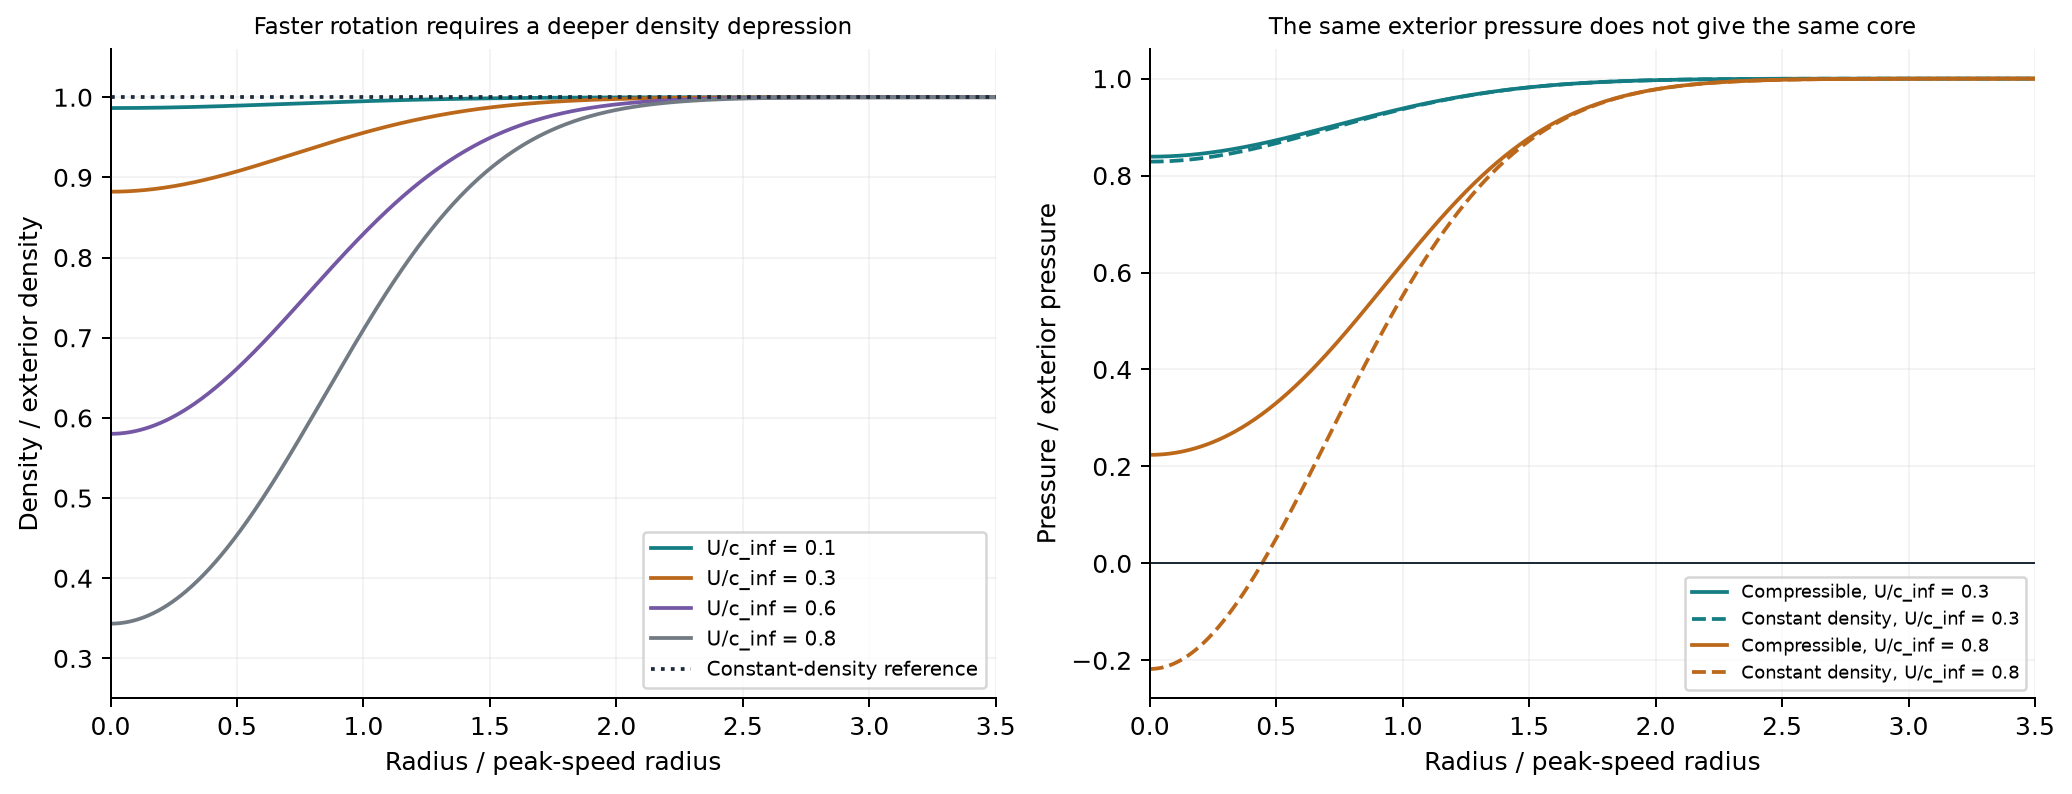

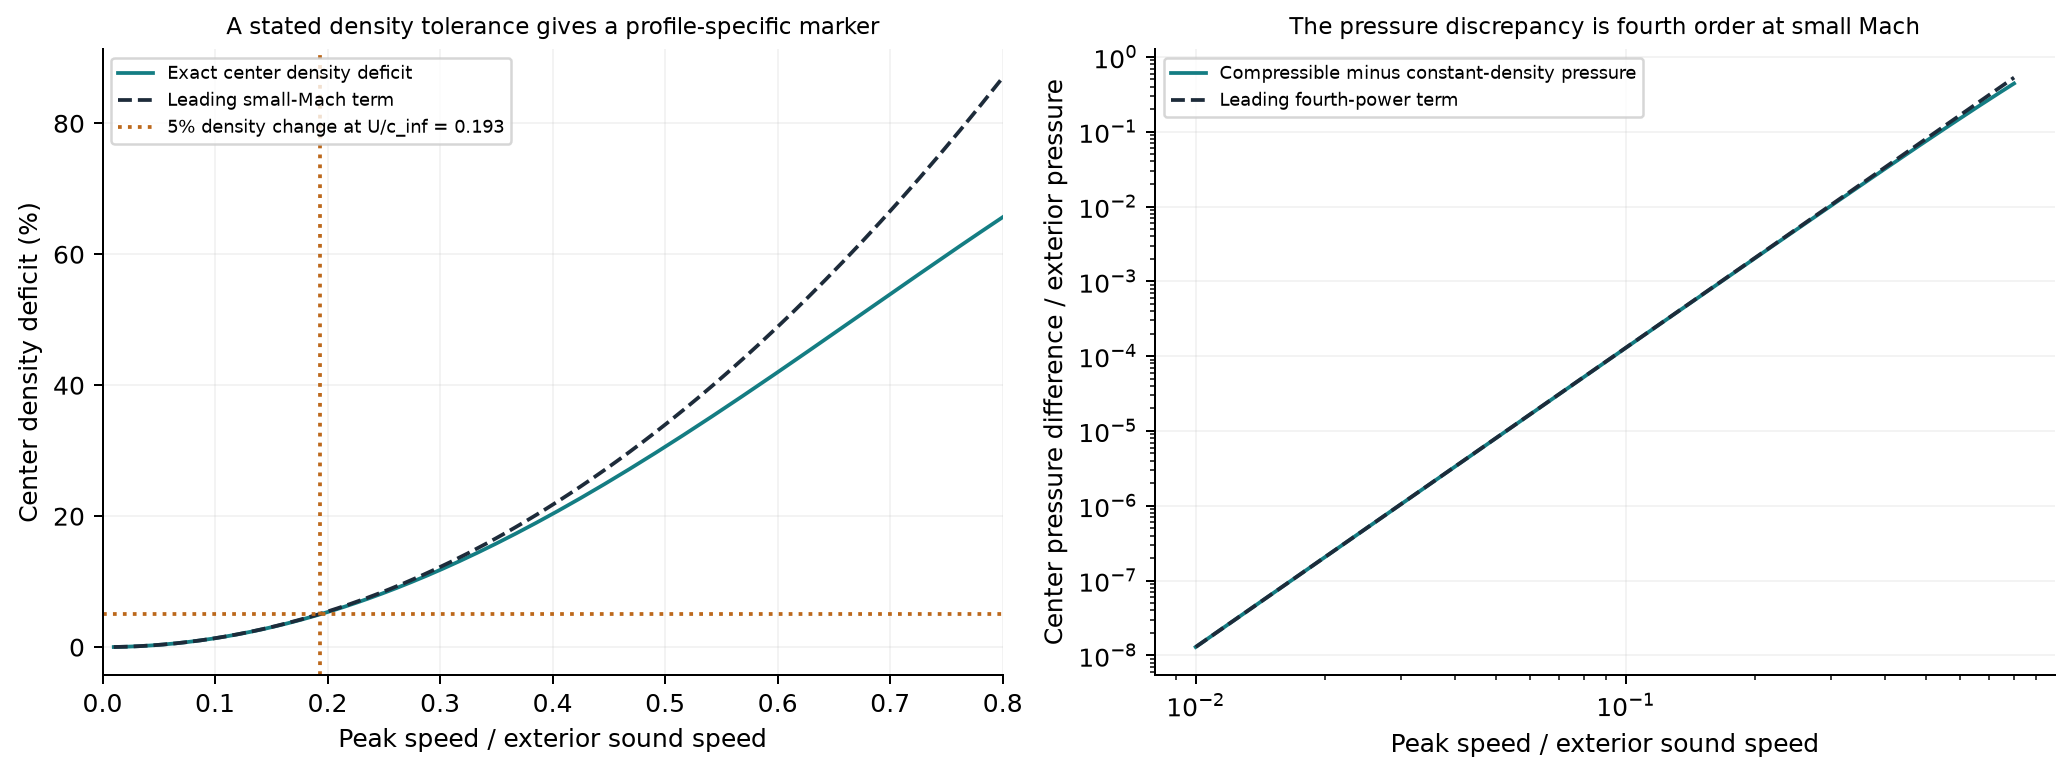

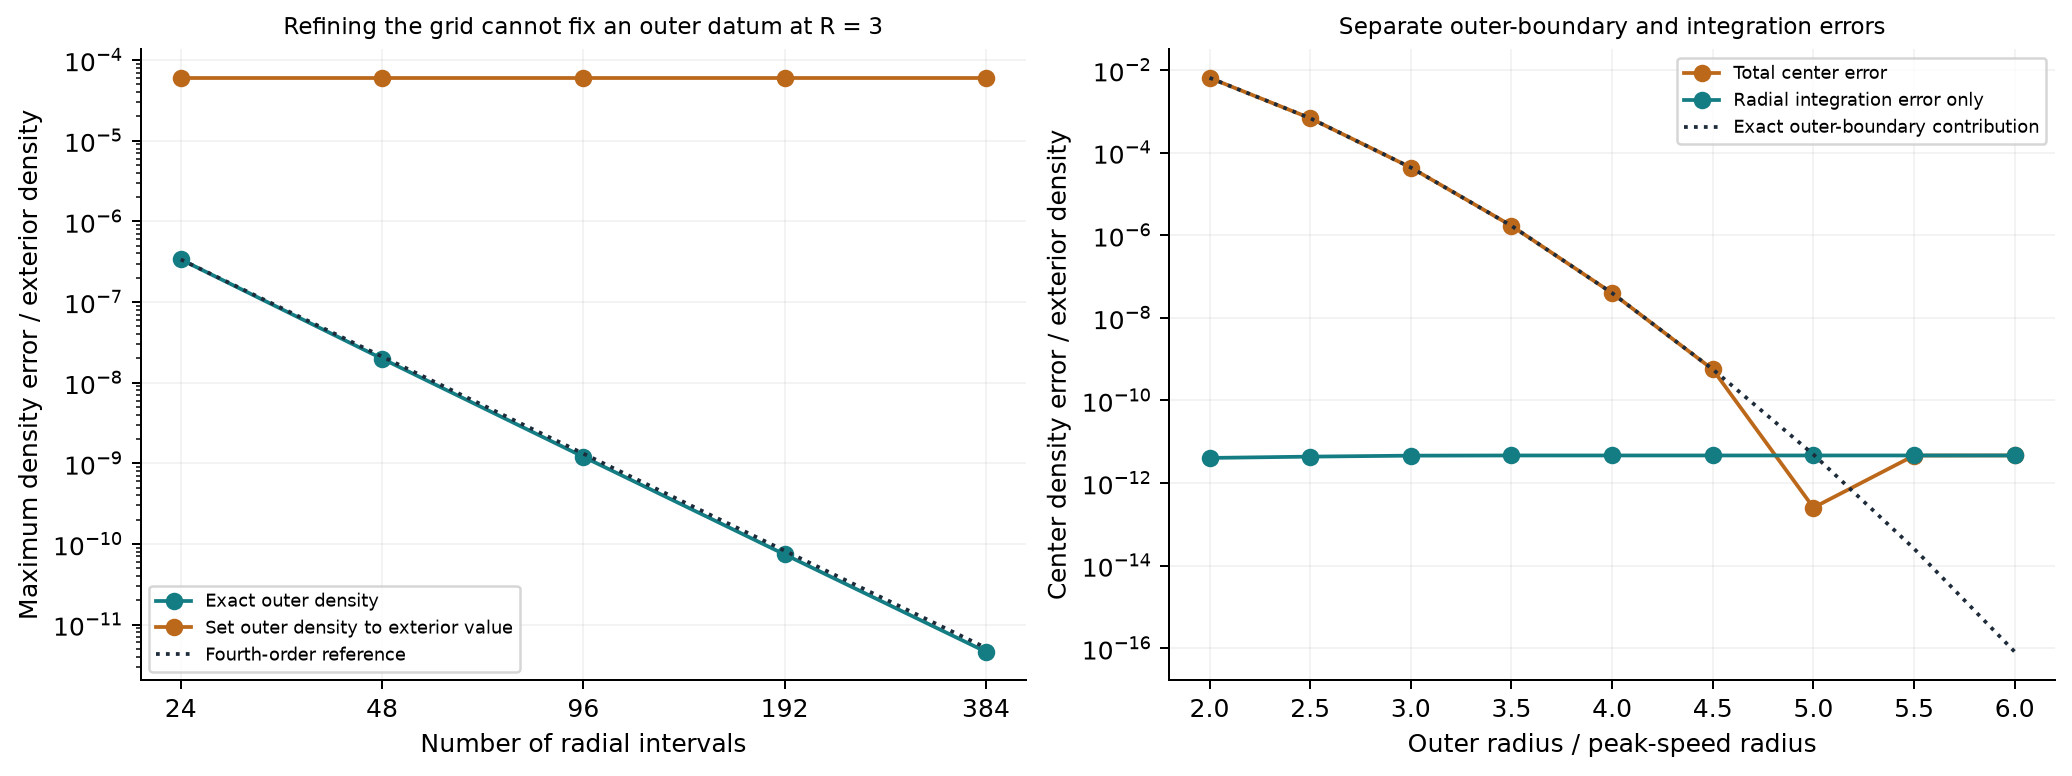

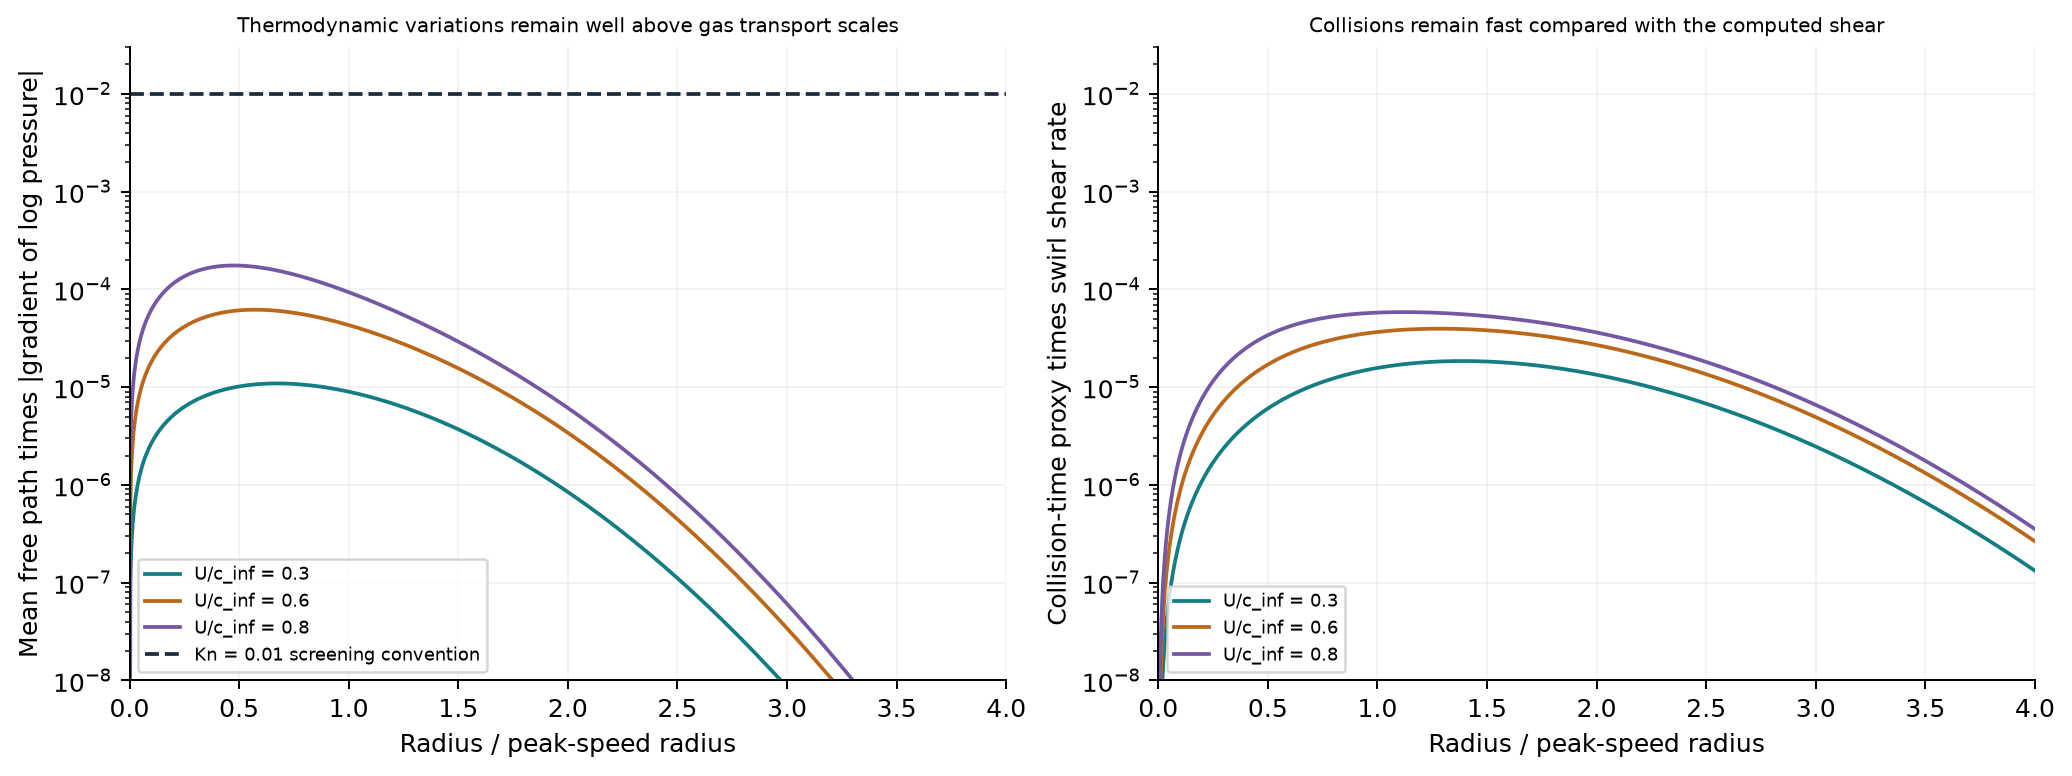

In [6]:
for name in ('01_density_and_pressure','02_departure_from_constant_density','03_radial_and_boundary_accuracy','04_local_gas_scale_check'):
    display(Image(filename=str(WRITING/'figures'/f'{name}.png')))